# Distance-CRP

> Compute and visualize distance-binned conditional response probabilities using semantic embeddings.

The distance-conditioned response probability (Distance-CRP) replaces serial
lags with semantic or spatial distances supplied by the caller.  Each recall
transition is assigned to a distance bin and availability is tallied as the set
of bins containing at least one unrecalled item at the moment of choice.

$$\text{CRP}(d) = \frac{\text{actual transitions in distance bin } d}{\text{available transitions in distance bin } d}$$

Downward-sloping curves indicate a semantic contiguity effect: participants
preferentially transition to items that are semantically similar to the
just-recalled item.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty to skip) |
| `ylim` | Y-axis limits or `None` for auto |
| `trial_query` | Query string for trial selection |
| `features_path` | Path to numpy feature embeddings |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jaxcmr.analyses.distcrp import (
    compute_distance_bin_edges,
    compute_distance_bins_percentiles,
    compute_distance_bins_min_count,
    compute_min_count_distance_bins,
    DistanceTabulation,
    dist_crp,
    plot_cat_crp,
    plot_dist_crp,
    raw_candidate_transitions,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.math import cosine_similarity_matrix

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
features_path = "data/peers-all-mpnet-base-v2.npy"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
features = np.load(os.path.join(project_root, features_path)).astype(np.float32)

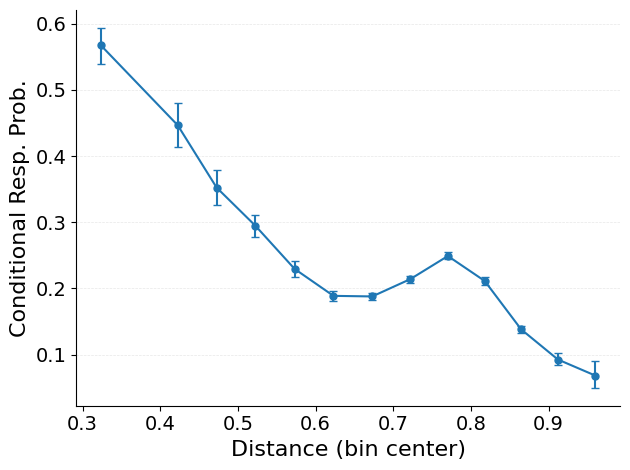

In [5]:
#| code-summary: Plot Distance-CRP
#| label: fig-distcrp
#| fig-cap: "Distance-CRP showing conditional response probability by semantic distance bin."
plot_dist_crp(
    datasets=data,
    trial_masks=trial_mask,
    features=features,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

`plot_dist_crp` computes cosine-distance bins from an embedding matrix and plots
the distance-CRP for one or more datasets.  To compare conditions within one
dataset, pass it multiple times with different masks.

In [6]:
#| echo: false
show_doc(plot_dist_crp)

---

### plot_dist_crp

>      plot_dist_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcm
>                     r.typing.RecallDataset], trial_masks:Union[Sequence[jaxtyp
>                     ing.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial
>                     _count']], features:jaxtyping.Float[Array,'word_countfeatu
>                     res_count'], color_cycle:Optional[list[str]]=None,
>                     labels:Optional[Sequence[str]]=None,
>                     contrast_name:Optional[str]=None,
>                     axis:Optional[matplotlib.axes._axes.Axes]=None,
>                     min_transitions_per_subject:int=10, bin_step:float=0.05,
>                     bin_source_index:int=0,
>                     bin_edges:Optional[jaxtyping.Float[Array,'edges']]=None,
>                     bin_centers:Optional[jaxtyping.Float[Array,'bins']]=None,
>                     confidence_level:float=0.95)

*Plot distance-binned CRP curves aggregated by subject.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Recall datasets to contrast. |
| trial_masks | Union |  | Boolean masks selecting trials per dataset. |
| features | Float[Array, 'word_count features_count'] |  | Feature matrix whose rows align with vocabulary items. |
| color_cycle | Optional | None | Colors for successive datasets. |
| labels | Optional | None | Legend labels for ``datasets``. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Matplotlib Axes to plot on. |
| min_transitions_per_subject | int | 10 | Minimum available transitions per bin per subject. |
| bin_step | float | 0.05 | Distance increment for expanding each bin. |
| bin_source_index | int | 0 | Dataset index providing binning availability counts. |
| bin_edges | Optional | None | Interior bin edges; computed from data if ``None``. |
| bin_centers | Optional | None | Bin centers matching ``bin_edges``. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with distance-binned CRP curves.** |

`plot_cat_crp` is a convenience wrapper that bins transitions into *same* vs.
*different* category using a single feature column.

In [7]:
#| echo: false
show_doc(plot_cat_crp)

---

### plot_cat_crp

>      plot_cat_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr
>                    .typing.RecallDataset], trial_masks:Union[Sequence[jaxtypin
>                    g.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial_co
>                    unt']],
>                    features:jaxtyping.Float[Array,'word_countfeatures_count'],
>                    feature_column:int=0, feature_label:str='Category',
>                    color_cycle:Optional[list[str]]=None,
>                    labels:Optional[Sequence[str]]=None,
>                    contrast_name:Optional[str]=None,
>                    axis:Optional[matplotlib.axes._axes.Axes]=None,
>                    confidence_level:float=0.95)

*Plot category-binned CRP curves from a single feature column.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Recall datasets to compare. |
| trial_masks | Union |  | Boolean masks selecting trials per dataset. |
| features | Float[Array, 'word_count features_count'] |  | Feature matrix; specified column encodes categories. |
| feature_column | int | 0 | Zero-based column index in ``features``. |
| feature_label | str | Category | Human-readable label for the feature column. |
| color_cycle | Optional | None | Colors for each dataset. |
| labels | Optional | None | Legend labels for ``datasets``. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Matplotlib Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with category-binned CRP curves.** |

`dist_crp` returns the distance-conditioned response probability for a single
dataset given pre-computed distance bins.

In [8]:
#| echo: false
show_doc(dist_crp)

---

### dist_crp

>      dist_crp (dataset:jaxcmr.typing.RecallDataset,
>                distance_matrix:jaxtyping.Float[Array,'item_countitem_count'],
>                bin_edges:jaxtyping.Float[Array,'edges'])

*Distance-conditioned response probability.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset with ``recalls`` and ``pres_itemids``. |
| distance_matrix | Float[Array, 'item_count item_count'] | Pairwise item distances. |
| bin_edges | Float[Array, 'edges'] | Interior boundaries for distance bins. |
| **Returns** | **Float[Array, 'bins']** | **Conditional response probability per distance bin.** |

In [9]:
# dist_crp returns one value per distance bin
distances = 1 - cosine_similarity_matrix(features)
edges, centers = compute_distance_bins_min_count(
    data, distances, min_transitions_per_subject=10, trial_mask=trial_mask
)
result = dist_crp(data, distances, edges)
assert result.shape[0] == edges.shape[0] + 1

### Tabulators

The distance-CRP functions above aggregate trial-level tabulations.
`tabulate_trial` handles a single trial, returning actual and available
transition counts per distance bin.

In [10]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      present_ids:jaxtyping.Integer[Array,'study_item_ids'], di
>                      stance_matrix:jaxtyping.Float[Array,'item_countitem_count
>                      '], bin_edges:jaxtyping.Float[Array,'edges'])

*Actual and available bin counts for a single trial.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trial | Integer[Array, 'recall_events'] | Recall events encoded as study positions. |
| present_ids | Integer[Array, 'study_item_ids'] | Item identifiers at each study position. |
| distance_matrix | Float[Array, 'item_count item_count'] | Pairwise distances indexed by item identifier. |
| bin_edges | Float[Array, 'edges'] | Interior bin edges shared across trials. |
| **Returns** | **tuple** | **Actual and available transition counts per bin.** |

### Binning utilities

Distance bins can be computed from percentiles or from minimum-count
availability constraints.

In [11]:
#| echo: false
show_doc(compute_distance_bins_percentiles)

---

### compute_distance_bins_percentiles

>      compute_distance_bins_percentiles
>                                         (distance_matrix:jaxtyping.Float[Array
>                                         ,'item_countitem_count'], percentiles:
>                                         jaxtyping.Float[Array,'percentiles'])

*Percentile-based distance bin edges and centers.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| distance_matrix | Float[Array, 'item_count item_count'] | Pairwise distances for the item vocabulary. |
| percentiles | Float[Array, 'percentiles'] | Percentiles (0--100) defining interior bin edges. |
| **Returns** | **tuple** | **``(interior_edges, bin_centers)`` where edges are the<br>percentile cut points and centers are bin midpoints.** |

In [12]:
# Percentile bins produce the expected number of edges
test_matrix = jnp.array([[0.0, 0.3, 0.7], [0.3, 0.0, 0.5], [0.7, 0.5, 0.0]])
edges_p, centers_p = compute_distance_bins_percentiles(
    test_matrix, jnp.array([33.0, 66.0])
)
assert edges_p.shape[0] == 2
assert centers_p.shape[0] == 3

In [13]:
#| echo: false
show_doc(compute_distance_bins_min_count)

---

### compute_distance_bins_min_count

>      compute_distance_bins_min_count (dataset:jaxcmr.typing.RecallDataset,
>                                       distance_matrix:jaxtyping.Float[Array,'i
>                                       tem_countitem_count'],
>                                       min_transitions_per_subject:int,
>                                       step:float=0.05, trial_mask:Optional[jax
>                                       typing.Bool[Array,'trial_count']]=None)

*Distance bins derived from dataset availability counts.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemids``. |
| distance_matrix | Float[Array, 'item_count item_count'] |  | Pairwise distances indexed by item identifier. |
| min_transitions_per_subject | int |  | Minimum available transitions per bin per subject. |
| step | float | 0.05 | Distance increment used while expanding each bin. |
| trial_mask | Optional | None | Mask selecting trials for bin computation. |
| **Returns** | **tuple** |  | **``(edges, centers)`` with interior boundaries and<br>mean distances per bin.** |

In [14]:
#| echo: false
show_doc(compute_min_count_distance_bins)

---

### compute_min_count_distance_bins

>      compute_min_count_distance_bins
>                                       (candidates:jaxtyping.Float[Array,'subje
>                                       ct_counttransition_count'], mask:jaxtypi
>                                       ng.Bool[Array,'subject_counttransition_c
>                                       ount'], min_transitions_per_subject:int,
>                                       step:float=0.05)

*Distance bins satisfying per-subject availability minimum.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| candidates | Float[Array, 'subject_count transition_count'] |  | Distance values for every available transition. |
| mask | Bool[Array, 'subject_count transition_count'] |  | Boolean mask selecting valid entries in ``candidates``. |
| min_transitions_per_subject | int |  | Minimum average available transitions per bin. |
| step | float | 0.05 | Increment used when widening the current bin. |
| **Returns** | **tuple** |  | **``(edges, centers)`` with interior bin boundaries and<br>mean distances per bin.** |

In [15]:
#| echo: false
show_doc(raw_candidate_transitions)

---

### raw_candidate_transitions

>      raw_candidate_transitions
>                                 (trial:jaxtyping.Integer[Array,'recall_events'
>                                 ], present_ids:jaxtyping.Integer[Array,'study_
>                                 item_ids'], distance_matrix:jaxtyping.Float[Ar
>                                 ray,'item_countitem_count'])

*Available transition distances per recall step.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trial | Integer[Array, 'recall_events'] | Recall events encoded as study positions. |
| present_ids | Integer[Array, 'study_item_ids'] | Item identifiers at each study position. |
| distance_matrix | Float[Array, 'item_count item_count'] | Pairwise item distances indexed by identifier. |
| **Returns** | **tuple** | **``(distances, mask)`` with distance candidates and<br>their availability mask per transition.** |

In [16]:
#| echo: false
show_doc(compute_distance_bin_edges)

---

### compute_distance_bin_edges

>      compute_distance_bin_edges
>                                  (distance_matrix:jaxtyping.Float[Array,'item_
>                                  countitem_count'], percentiles:jaxtyping.Floa
>                                  t[Array,'percentiles'])

*Deprecated alias for :func:`compute_distance_bins_percentiles`.*